In [ ]:
import torch
from torch.utils.data import DataLoader
from scripts.models import SWEUNet
from scripts.train import train, cos_lat_weights
from scripts.utils import CachedDataset
import json

# ===================== Experiment 1 config =====================
# Full-res global first pass: per-frame bias-correction, all 17 leads in one shot.
# Ensemble was pre-pooled in the cache (pool_ensemble=True) -> e_pooled=True here.
exp_name = 'exp2_fullres_RussiaCrop_T_flatten_E_meanstd'

ds_name = 'Contigous_Russia_Dataset'

pth = f'/Users/a1/Desktop/arpp/dborisov/database/cached/{ds_name}'
train_ds_cached = CachedDataset(f'{pth}/train')
test_ds_cached  = CachedDataset(f'{pth}/test')

train_loader = DataLoader(train_ds_cached, batch_size=2, shuffle=True,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds_cached,  batch_size=2, num_workers=4)

cfg = {
    'name': exp_name,
    # ---- model (read by SWEUNet) ----
    'work_hw':       [177, 717], #[180,720],#[361, 1440],   # full ERA grid; INM (91x360) is upsampled onto it
    'e_pooled':      True,          # cache holds (mean,std) over E -> skip runtime e_pool
    't_collapse':    'flatten',     # exp1 history collapse: fold the Ts window into channels
    'base':          16,#32,        # stem width; channels double each level
    'depth':         4,#5,          # 5 downsamples -> bottleneck ~12x45; keeps O(N^2) attn tractable
    'cond_dim':      32,            # FiLM conditioning width (lead + season)
    'n_freqs':       6,             # lead sinusoidal-encoding frequency count
    'max_lead_days': 120.0,         # leads span 0..112 d (17 weekly frames)
    'attn_heads':    4,             # bottleneck spatial self-attention heads
    # ---- training (splat into train(); see scripts/train.py) ----
    'train': {
        'epochs':        30,
        'lr':            3e-3,
        'weight_decay':  1e-4,
        'scheduler':     'cosine',
        'warmup_epochs': 5,
        'min_lr':        1e-6,
        'grad_clip':     1.0,
        'target_key':    'target_sd_log_17weeks',
        #'persist_key':   'hist_sd_log_6weeks',   # last obs anomaly -> persistence baseline
        'out_dir':       f'/Users/a1/Desktop/arpp/dborisov/experiments/{exp_name}/evaluate_checkpoints',
        'save_weights':  'best'
    },
}

model = SWEUNet(cfg)

lat_w = cos_lat_weights(0, 90, cfg['work_hw'][0])   # 361 rows, global extent

with open(f'database/norms/{ds_name}/{ds_name}.json', 'r', encoding='utf-8') as file:
    norm_stats = json.load(file)['channels']

history = train(model, train_loader, test_loader,
                lat_weights=lat_w,
                norm_stats=norm_stats,        # CachedDataset has none; reuse the source ds
                **cfg['train'])




/Users/a1/Desktop/arpp/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


epoch 1/30:   0%|          | 0/180 [00:00<?, ?it/s]

eval:   0%|          | 0/9 [00:00<?, ?it/s]

epoch   1 | lr 8.40e-04 | train_mse 0.4084 | RMSE 0.6733  ACC 0.378  RMSESS +0.063


epoch 2/30:   0%|          | 0/180 [00:00<?, ?it/s]

...

eval:   0%|          | 0/9 [00:00<?, ?it/s]

epoch  29 | lr 1.28e-05 | train_mse 0.3317 | RMSE 0.6336  ACC 0.476  RMSESS +0.119


epoch 30/30:   0%|          | 0/180 [00:00<?, ?it/s]

eval:   0%|          | 0/9 [00:00<?, ?it/s]

epoch  30 | lr 1.00e-06 | train_mse 0.3338 | RMSE 0.6337  ACC 0.476  RMSESS +0.119


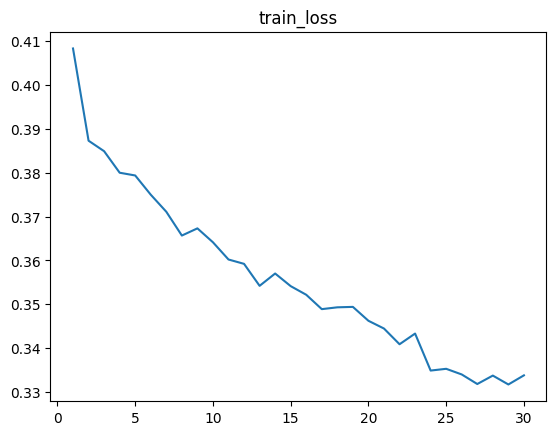

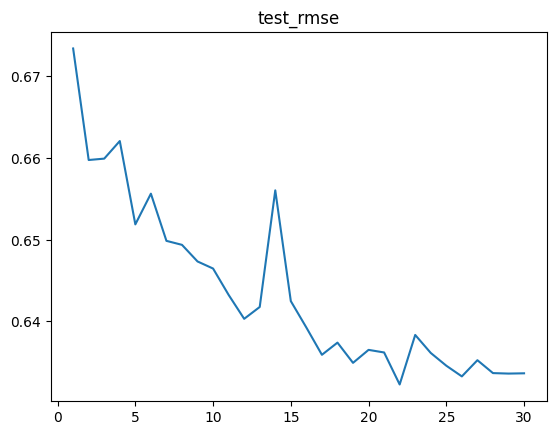

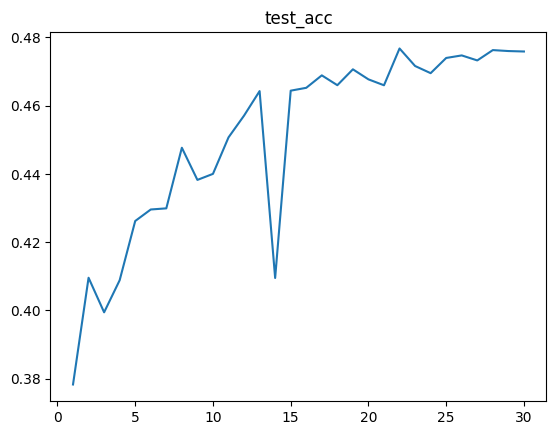

In [2]:
import matplotlib.pyplot as plt

epochs = [r['epoch'] for r in history]

for k in ['train_loss', 'test_rmse', 'test_acc']:
    plt.plot(epochs, [r[k] for r in history])
    plt.title(k)
    plt.show()